In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.datasets import load_diabetes


In [2]:
diabetics=load_diabetes()
data=load_diabetes(as_frame=True).frame

In [3]:
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
data.shape

(442, 11)

In [5]:
data.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


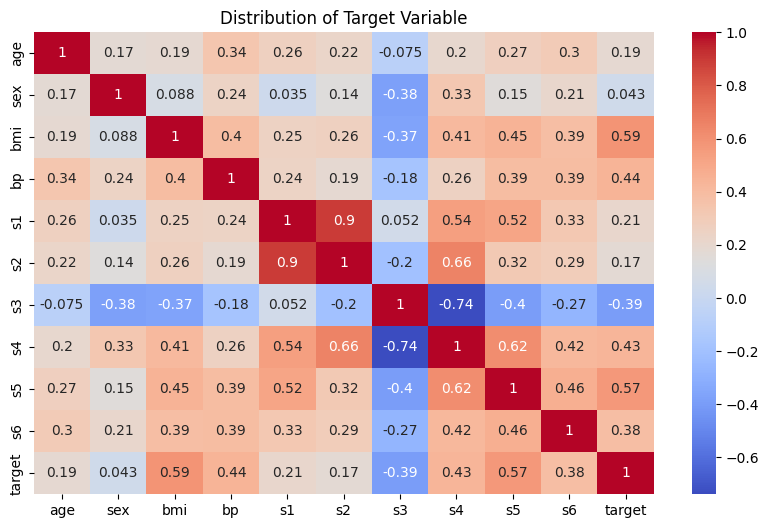

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("Distribution of Target Variable")
plt.show()

In [8]:
X=data.drop('target',axis=1)
y=data['target']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [11]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(353, 10)
(89, 10)


In [12]:
print(X_train_scaled)

[[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]


In [13]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [14]:
import joblib
joblib.dump(model,'diabetes_model.pkl')
joblib.dump(scalar,'diabetes_scalar.pkl')
print("Model saved as diabetes_model.pkl")
print("Scalar saved as diabetes_scalar.pkl")

Model saved as diabetes_model.pkl
Scalar saved as diabetes_scalar.pkl


In [15]:
y_pred=model.predict(X_test_scaled)

In [16]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("R-squared:",r2)
print("Model coefficients:",model.coef_)
print("Intercept:",model.intercept_)
                

Mean Squared Error: 2900.1936284934827
R-squared: 0.45260276297191915
Model coefficients: [  1.75375799 -11.51180908  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  13.1387839   35.16119521   2.35136365]
Intercept: 153.73654390934846


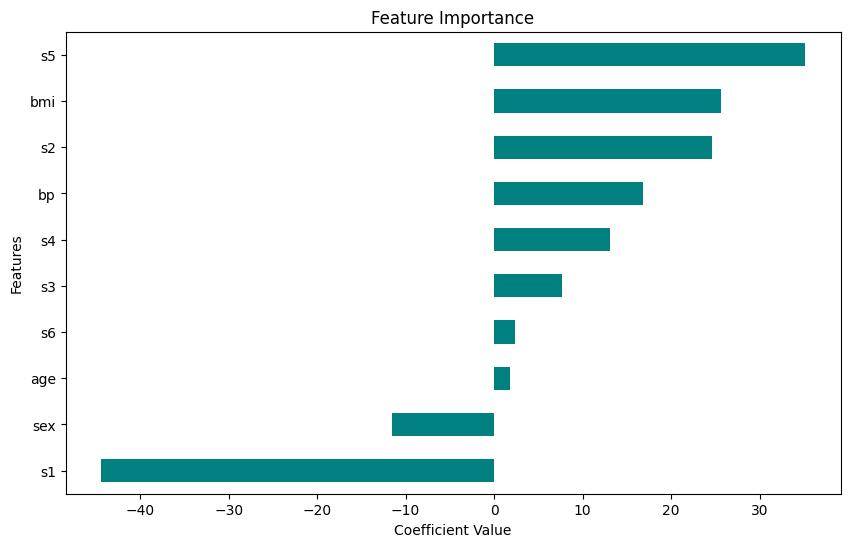

In [17]:
feature_importance=pd.Series(model.coef_,index=X.columns)
plt.figure(figsize=(10,6))
feature_importance.sort_values().plot(kind='barh',color='teal')
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


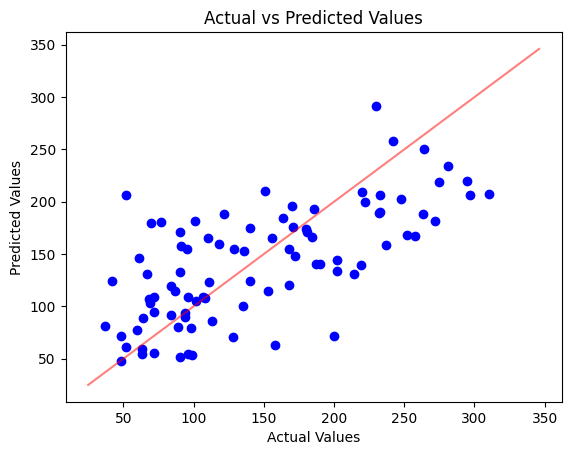

In [18]:
plt.scatter(y_test,y_pred,color='blue')
plt.plot([y.min(),y.max()],[y.min(),y.max()],color='red',alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()  

In [19]:
sample_input=np.array([[0.05,0.03,0.04,0.02,0.01,0.03,0.02,0.01,0.02,0.03]])
sample_input_scaled=scalar.transform(sample_input)
sample_prediction=model.predict(sample_input_scaled)
print("Predicted target value for the sample input:",sample_prediction[0])

Predicted target value for the sample input: 203.0657573842406


c:\Users\kripa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
